# Task 1.4 — log the uncertainty proxies over 50 ImageNet classes

Pretrained **DiT-XL/2** (ImageNet-256), **inference only, no retraining**.

Per class we do **one batched reverse pass**:
- the `K` seeds are batched together, so a single `p_sample_loop_progressive` gives all of them;
- at every step we take $\mathrm{Var}_k[\hat x_0]$ and pool it onto the **16×16 patch grid**
  (DiT-XL/2: patch 2 on a 32×32 latent → 256 tokens);
- attention entropy is captured **during that same pass**, so it is averaged over the `K` seeds
  for free instead of resting on a single trajectory.

$U_\text{route}$ is left as `NaN`: it needs a **TREAD-trained** DiT-XL/2 checkpoint, which is not
publicly released. The column exists so the CSV has the Task-1 schema.

**Runtime:** ≈1 min per class on an RTX 4070 → ~50 min for the full panel.
Run the smoke test (§5) first — it takes ~1 min and tells you everything works.

## 1 · Load the pretrained DiT-XL/2

In [1]:
import os, sys, types, time
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

REPO = os.getcwd()
sys.path.insert(0, os.path.join(REPO, "DiT"))
from diffusion import create_diffusion
from models import DiT_XL_2

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"

model = DiT_XL_2(input_size=32).to(device)
state = torch.load(os.path.join(REPO, "DiT", "DiT-XL-2-256x256.pt"), map_location=device)
state = state.get("ema", state) if isinstance(state, dict) and "ema" in state else state
model.load_state_dict(state); model.eval()
DEPTH = len(model.blocks)

print(f"DiT-XL/2: {sum(p.numel() for p in model.parameters())/1e6:.0f}M params, "
      f"{DEPTH} blocks, device={device}")

/home/jovyan/venv/diffusion/venv_base/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DiT-XL/2: 675M params, 28 blocks, device=cuda


## 2 · Config + the 50-class panel

Stratification criterion — **expected difficulty of $p(x\mid c)$**:

| tier | what | examples |
|---|---|---|
| easy | one canonical object, plain background, ~unimodal | lemon, orange, golf ball |
| medium | one object, real pose / lighting / background variation | golden retriever, zebra, macaw |
| hard | polysemous label, cluttered multi-object scene | **crane ×2**, restaurant, coral reef |

The panel deliberately contains **951 (lemon)** — the reference class in the team's slide — and
**both senses of "crane": 134 (bird) and 517 (machine)**, which is the ambiguity the proposal
itself singles out as the key comparison.

> The proposal asks to stratify *"by expected FID contribution"*. Per-class FID needs real
> ImageNet reference images; we stratify semantically instead and flag FID-based stratification
> as future work. Say this out loud at the defence.

In [2]:
K_SEEDS   = 32     # proposal: K = 16
STEPS     = 250    # sampling steps along the reverse path
N_BINS    = 20     # timestep bins: t in [0,1000) -> centres 25, 75, ... 975
CFG_SCALE = 1.0    # 1.0 = pure conditional. Guidance inflates Var_k by a class-independent
                   # factor, so it would not change the SHAPE of U_ens but would change its
                   # scale. Set >1 only if the rest of the team did — then say so on the slide.
LATENT, PATCH = 32, 2
GRID = LATENT // PATCH          # 16x16 patch grid

CLASS_PANEL = [
    # ---- easy (17) ----
    (951, "lemon", "easy"),            (950, "orange", "easy"),
    (949, "strawberry", "easy"),       (948, "Granny Smith", "easy"),
    (954, "banana", "easy"),           (953, "pineapple", "easy"),
    (957, "pomegranate", "easy"),      (945, "bell pepper", "easy"),
    (937, "broccoli", "easy"),         (988, "acorn", "easy"),
    (985, "daisy", "easy"),            (574, "golf ball", "easy"),
    (852, "tennis ball", "easy"),      (429, "baseball", "easy"),
    (430, "basketball", "easy"),       (971, "bubble", "easy"),
    (892, "wall clock", "easy"),
    # ---- medium (17) ----
    (207, "golden retriever", "medium"), (235, "German shepherd", "medium"),
    (250, "Siberian husky", "medium"),   (281, "tabby cat", "medium"),
    (285, "Egyptian cat", "medium"),     (291, "lion", "medium"),
    (292, "tiger", "medium"),            (340, "zebra", "medium"),
    (360, "otter", "medium"),            (387, "lesser panda", "medium"),
    (388, "giant panda", "medium"),      (88,  "macaw", "medium"),
    (130, "flamingo", "medium"),         (145, "king penguin", "medium"),
    (850, "teddy bear", "medium"),       (817, "sports car", "medium"),
    (779, "school bus", "medium"),
    # ---- hard (16) ----
    (134, "crane (bird)", "hard"),     (517, "crane (machine)", "hard"),
    (762, "restaurant", "hard"),       (454, "bookshop", "hard"),
    (624, "library", "hard"),          (582, "grocery store", "hard"),
    (865, "toyshop", "hard"),          (973, "coral reef", "hard"),
    (974, "geyser", "hard"),           (975, "lakeside", "hard"),
    (979, "valley", "hard"),           (980, "volcano", "hard"),
    (972, "cliff", "hard"),            (978, "seashore", "hard"),
    (933, "cheeseburger", "hard"),     (963, "pizza", "hard"),
]

panel_df = pd.DataFrame(CLASS_PANEL, columns=["class_id", "class_name", "difficulty"])
print(panel_df.difficulty.value_counts().to_string(), f"\ntotal: {len(panel_df)} classes")
panel_df.head(3)

difficulty
easy      17
medium    17
hard      16 
total: 50 classes


,class_id,class_name,difficulty
0,951,lemon,easy
1,950,orange,easy
2,949,strawberry,easy


## 3 · Attention-entropy capture

DiT's blocks use timm's `Attention`, whose **fused SDPA kernel never materialises the softmax
weights** — so there is nothing to hook. We temporarily swap in an eager forward that exposes
$A$, accumulate the per-query Shannon entropy, and restore the original afterwards.

We report the **mean per-query** entropy (averaged over queries, heads, seeds) rather than the
proposal's literal $-\sum_{ij}A_{ij}\log A_{ij}$ — the two differ by a factor of $N$. The mean is
bounded by $\ln N=\ln 256=5.545$, which gives the curve an **interpretable ceiling**: sitting on
it means attention is uniform, i.e. the block is not selecting anything.

In [3]:
_ENTROPY = {}

def _eager_forward_with_entropy(layer_idx):
    def forward(self, x):
        B, N, C = x.shape
        nh, hd = self.num_heads, C // self.num_heads
        qkv = self.qkv(x).reshape(B, N, 3, nh, hd).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        if hasattr(self, "q_norm"): q = self.q_norm(q)
        if hasattr(self, "k_norm"): k = self.k_norm(k)
        attn = (q * getattr(self, "scale", hd ** -0.5)) @ k.transpose(-2, -1)
        attn = attn.softmax(dim=-1)                              # (B, nh, N, N)

        ent = -(attn * attn.clamp_min(1e-12).log()).sum(-1)      # (B, nh, N)
        _ENTROPY[layer_idx] = float(ent.mean().item())           # over seeds / heads / queries

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return self.proj_drop(x) if hasattr(self, "proj_drop") else x
    return forward

def enable_capture():
    for i, blk in enumerate(model.blocks):
        if not hasattr(blk.attn, "_orig_forward"):
            blk.attn._orig_forward = blk.attn.forward
        blk.attn.forward = types.MethodType(_eager_forward_with_entropy(i), blk.attn)

def disable_capture():
    for blk in model.blocks:
        if hasattr(blk.attn, "_orig_forward"):
            blk.attn.forward = blk.attn._orig_forward
            del blk.attn._orig_forward

print("attention capture ready")

attention capture ready


## 4 · The proxies

$$U_\text{ens}(t,c)=\mathrm{Var}_k\big[D_\theta(x_t^{(k)},t,c)\big],\qquad
U_\text{attn}(t,\ell)=-\textstyle\sum_j A^{(\ell)}_{ij}\log A^{(\ell)}_{ij}$$

Variance is taken **across seeds first**, then pooled inside each 2×2 latent patch (the DiT
token footprint) and across channels — that order matters, it is what makes it *per-patch*.

In [4]:
def patch_variance(x0):
    # (K,C,H,W) x0-predictions -> (GRID,GRID) per-patch variance across seeds
    var = x0.float().var(dim=0, unbiased=False)                  # (C,H,W)
    c, h, w = var.shape
    return var.reshape(c, h // PATCH, PATCH, w // PATCH, PATCH).mean(dim=(0, 2, 4))


@torch.no_grad()
def run_class(cls, k=K_SEEDS, steps=STEPS, cfg=CFG_SCALE):
    # one batched reverse pass -> (timesteps, per-patch U_ens maps, per-layer U_attn)
    diff = create_diffusion(str(steps))
    ts = [diff.timestep_map[i] for i in range(diff.num_timesteps - 1, -1, -1)]

    torch.manual_seed(1234 + cls)
    z = torch.randn(k, 4, LATENT, LATENT, device=device)

    if cfg == 1.0:
        fn, z_in, shape = model.forward, z, z.shape
        model_kwargs = dict(y=torch.full((k,), cls, device=device, dtype=torch.long))
    else:
        fn = model.forward_with_cfg
        z_in = torch.cat([z, z], 0); shape = z_in.shape
        y = torch.cat([torch.full((k,), cls,  device=device, dtype=torch.long),
                       torch.full((k,), 1000, device=device, dtype=torch.long)])
        model_kwargs = dict(y=y, cfg_scale=cfg)

    maps, per_layer = [], []
    enable_capture()
    try:
        for out in diff.p_sample_loop_progressive(
            fn, shape, z_in, clip_denoised=False,
            model_kwargs=model_kwargs, device=device, progress=False,
        ):
            maps.append(patch_variance(out["pred_xstart"][:k]).cpu().numpy())
            per_layer.append([_ENTROPY[i] for i in range(DEPTH)])
    finally:
        disable_capture(); _ENTROPY.clear()

    return np.array(ts), np.stack(maps), np.array(per_layer)     # (T,), (T,G,G), (T,DEPTH)


def bin_curve(t_vals, y_vals, n_bins=N_BINS, t_max=1000):
    edges = np.linspace(0, t_max, n_bins + 1)
    idx = np.clip(np.digitize(np.asarray(t_vals, float), edges) - 1, 0, n_bins - 1)
    out = np.full(n_bins, np.nan)
    for b in range(n_bins):
        m = idx == b
        if m.any():
            out[b] = np.asarray(y_vals, float)[m].mean()
    return out, ((edges[:-1] + edges[1:]) / 2).astype(int)

print("proxies ready")

proxies ready


## 5 · Smoke test — one class (~1 min)

Run this before the full panel. Expected shape, and worth internalising **before** the defence:

- $U_\text{ens}$ **starts low, dips around $t\approx900$, then grows monotonically** toward $t=0$.
- $U_\text{attn}$ **falls** from ≈5.3 nats toward ≈3.5 as the path is denoised.

class 951 (lemon): 100 steps, patch grid 16x16  [3s]
  U_ens : 0.0630 (t=999)  ->  0.7106 (t=0)
  U_attn: 5.29   (t=999)  ->  3.64   (t=0)   [max = ln256 = 5.55]


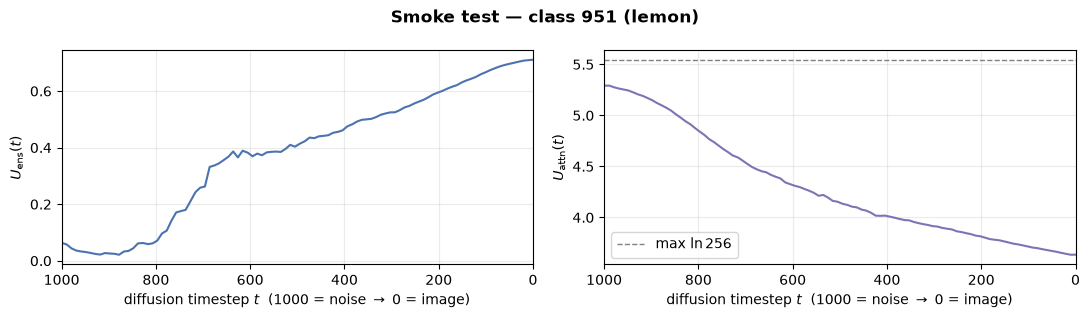

In [5]:
t0 = time.time()
ts, maps, per_layer = run_class(951, k=8, steps=100)   # small settings, just to check
u_ens, u_attn = maps.mean(axis=(1, 2)), per_layer.mean(1)
print(f"class 951 (lemon): {len(ts)} steps, patch grid {maps.shape[1]}x{maps.shape[2]}  "
      f"[{time.time()-t0:.0f}s]")
print(f"  U_ens : {u_ens[0]:.4f} (t={ts[0]})  ->  {u_ens[-1]:.4f} (t={ts[-1]})")
print(f"  U_attn: {u_attn[0]:.2f}   (t={ts[0]})  ->  {u_attn[-1]:.2f}   (t={ts[-1]})   "
      f"[max = ln256 = {np.log(256):.2f}]")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(ts, u_ens, color="#4C72B0"); ax[0].set_ylabel(r"$U_\mathrm{ens}(t)$")
ax[1].plot(ts, u_attn, color="#8172B3"); ax[1].set_ylabel(r"$U_\mathrm{attn}(t)$")
ax[1].axhline(np.log(256), color="grey", ls="--", lw=1, label=r"max $\ln 256$"); ax[1].legend()
for a in ax:
    a.set_xlim(1000, 0)                       # t descending: noise -> image
    a.set_xlabel(r"diffusion timestep $t$  (1000 = noise $\rightarrow$ 0 = image)")
    a.grid(alpha=.25)
fig.suptitle("Smoke test — class 951 (lemon)", fontweight="bold")
plt.tight_layout(); plt.show()

## 6 · Full panel — 50 classes × 20 bins

≈1 min per class on an RTX 4070 → **~50 minutes**. The progress bar shows live ETA.

In [6]:
records, heatmaps = [], {}
pbar = tqdm(CLASS_PANEL, desc="classes")
for cls, name, tier in pbar:
    pbar.set_postfix_str(f"{cls} {name}")
    ts, maps, per_layer = run_class(cls)

    b_ens,  centres = bin_curve(ts, maps.mean(axis=(1, 2)))
    b_attn, _ = bin_curve(ts, per_layer.mean(1))
    b_b0,   _ = bin_curve(ts, per_layer[:, 0])
    b_bmid, _ = bin_curve(ts, per_layer[:, DEPTH // 2])
    b_blast,_ = bin_curve(ts, per_layer[:, -1])

    for b in range(N_BINS):
        records.append({
            "class_id": cls, "class_name": name, "difficulty": tier,
            "bin": b, "t_centre": int(centres[b]),
            "U_ens": b_ens[b],
            "U_route": np.nan,                      # needs a TREAD DiT-XL/2 checkpoint
            "U_attn": b_attn[b],
            "U_attn_block0": b_b0[b],
            "U_attn_block14": b_bmid[b],
            "U_attn_block27": b_blast[b],
        })

    order = np.argsort(ts)                          # ascending t
    early, mid, late = order[-1], order[len(order) // 2], order[0]
    heatmaps[str(cls)] = np.stack([maps[early], maps[mid], maps[late]])
    heatmaps[f"{cls}_t"] = np.array([ts[early], ts[mid], ts[late]])

df = pd.DataFrame(records)
os.makedirs("results", exist_ok=True)
df.to_csv("results/task1_panel50.csv", index=False)
np.savez_compressed("results/task1_panel50_patchmaps.npz", **heatmaps)
print(f"saved -> results/task1_panel50.csv  {df.shape}")
df.head()

classes: 100%|██████████| 50/50 [22:53<00:00, 27.48s/it, 963 pizza]           

saved -> results/task1_panel50.csv  (1000, 11)


,class_id,class_name,difficulty,bin,t_centre,U_ens,U_route,U_attn,U_attn_block0,U_attn_block14,U_attn_block27
0,951,lemon,easy,0,25,0.750789,NaN,3.612398,5.454117,3.797675,3.546219
1,951,lemon,easy,1,75,0.727221,NaN,3.670481,5.425654,3.866995,3.709753
2,951,lemon,easy,2,125,0.693398,NaN,3.723481,5.411228,3.942978,3.791121
3,951,lemon,easy,3,175,0.654508,NaN,3.775166,5.401506,4.013361,3.857652
4,951,lemon,easy,4,225,0.617514,NaN,3.821886,5.395360,4.076475,3.915214


## 7 · Figures for the deck

In [7]:
LN256 = np.log(256)
TIERS = ["easy", "medium", "hard"]
TIER_COLOR = {"easy": "#4C72B0", "medium": "#DD8452", "hard": "#C44E52"}
os.makedirs("figures", exist_ok=True)
plt.rcParams.update({"figure.dpi": 130, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

def denoise_axis(ax):
    ax.set_xlim(1000, 0)
    ax.set_xlabel(r"diffusion timestep $t$  (1000 = noise $\rightarrow$ 0 = image)")

### fig 1 — Task 1.4 deliverable: 50 classes × 20 timestep bins

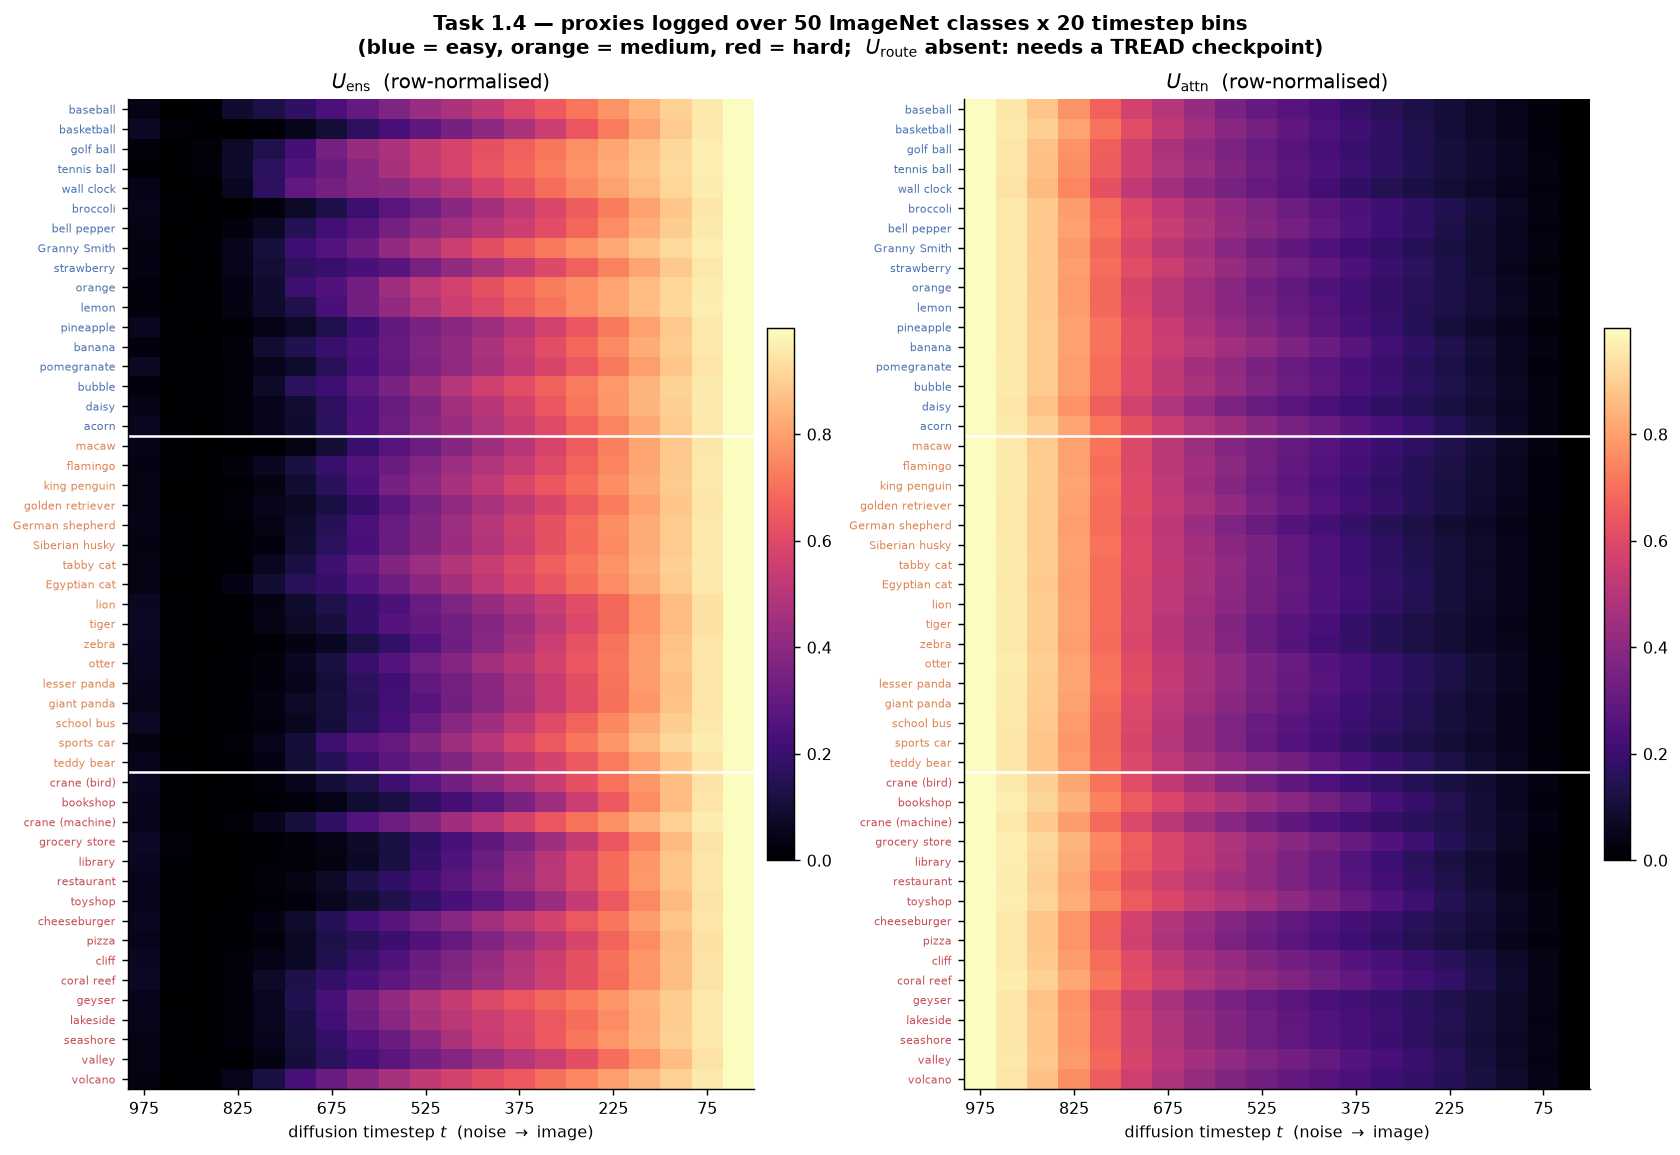

In [8]:
df["tier_rank"] = df.difficulty.map({t: i for i, t in enumerate(TIERS)})
order = df.sort_values(["tier_rank", "class_id"]).class_id.drop_duplicates().tolist()
names = {c: df[df.class_id == c].class_name.iloc[0] for c in order}
tiers = {c: df[df.class_id == c].difficulty.iloc[0] for c in order}
centres = np.sort(df.t_centre.unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 9))
for ax, proxy in zip(axes, ["U_ens", "U_attn"]):
    M = np.stack([df[df.class_id == c].sort_values("t_centre", ascending=False)[proxy].values
                  for c in order])
    Mn = (M - M.min(1, keepdims=True)) / (np.ptp(M, axis=1, keepdims=True) + 1e-9)
    im = ax.imshow(Mn, aspect="auto", cmap="magma", interpolation="nearest")
    ax.set_xticks(range(0, len(centres), 3))
    ax.set_xticklabels(sorted(centres, reverse=True)[::3])
    ax.set_xlabel(r"diffusion timestep $t$  (noise $\rightarrow$ image)")
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([names[c] for c in order], fontsize=6)
    for lbl, c in zip(ax.get_yticklabels(), order):
        lbl.set_color(TIER_COLOR[tiers[c]])
    ax.set_title(rf"$U_\mathrm{{{proxy.split('_')[1]}}}$  (row-normalised)")
    ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=.04, pad=.02)
    for b in np.cumsum([sum(1 for c in order if tiers[c] == t) for t in TIERS])[:-1]:
        ax.axhline(b - .5, color="w", lw=1.4)
fig.suptitle("Task 1.4 — proxies logged over 50 ImageNet classes x 20 timestep bins\n"
             r"(blue = easy, orange = medium, red = hard;  $U_\mathrm{route}$ absent: needs a TREAD checkpoint)",
             fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig("figures/fig1_class_bin_heatmap.png", bbox_inches="tight"); plt.show()

### fig 2 — timestep profiles by difficulty tier

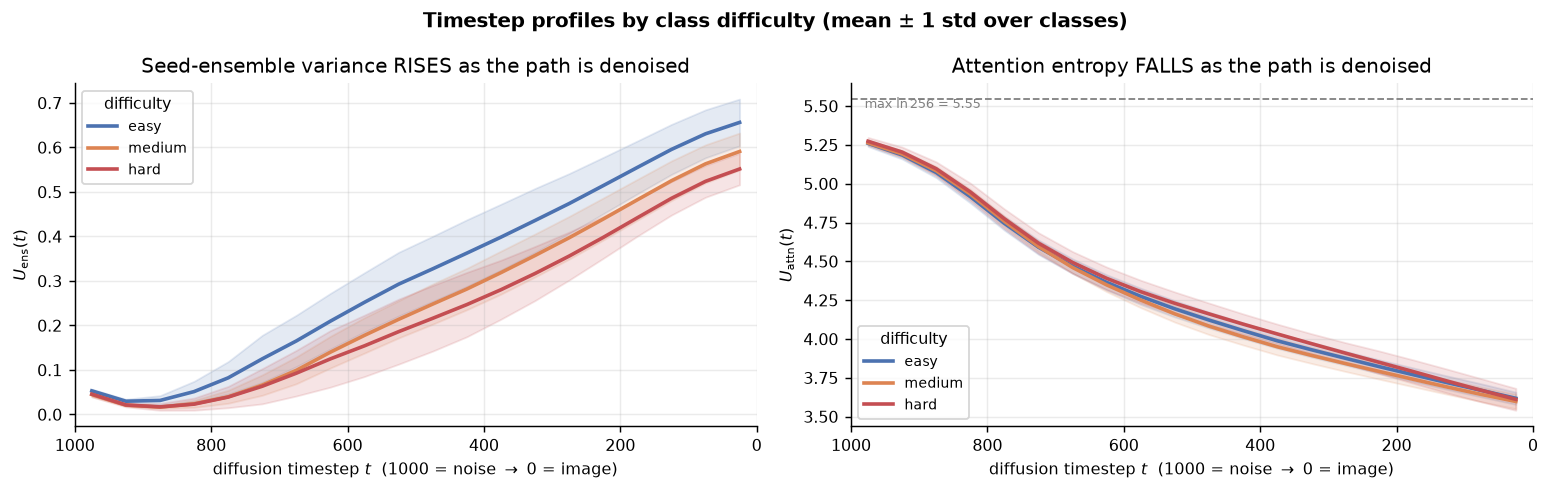

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, proxy, lab in zip(axes, ["U_ens", "U_attn"],
                          [r"$U_\mathrm{ens}(t)$", r"$U_\mathrm{attn}(t)$"]):
    for tier in TIERS:
        g = df[df.difficulty == tier].groupby("t_centre")[proxy]
        m, s = g.mean(), g.std()
        ax.plot(m.index, m.values, color=TIER_COLOR[tier], lw=2, label=tier)
        ax.fill_between(m.index, m - s, m + s, color=TIER_COLOR[tier], alpha=.15)
    denoise_axis(ax); ax.set_ylabel(lab); ax.legend(title="difficulty", fontsize=8)
axes[1].axhline(LN256, color="grey", ls="--", lw=1)
axes[1].text(980, LN256 - .06, rf"max $\ln 256$ = {LN256:.2f}", fontsize=7, color="grey")
axes[0].set_title("Seed-ensemble variance RISES as the path is denoised")
axes[1].set_title("Attention entropy FALLS as the path is denoised")
fig.suptitle(r"Timestep profiles by class difficulty (mean $\pm$ 1 std over classes)",
             fontweight="bold")
plt.tight_layout(); plt.savefig("figures/fig2_difficulty_curves.png", bbox_inches="tight"); plt.show()

### fig 3 — attention entropy per block (early / mid / late)

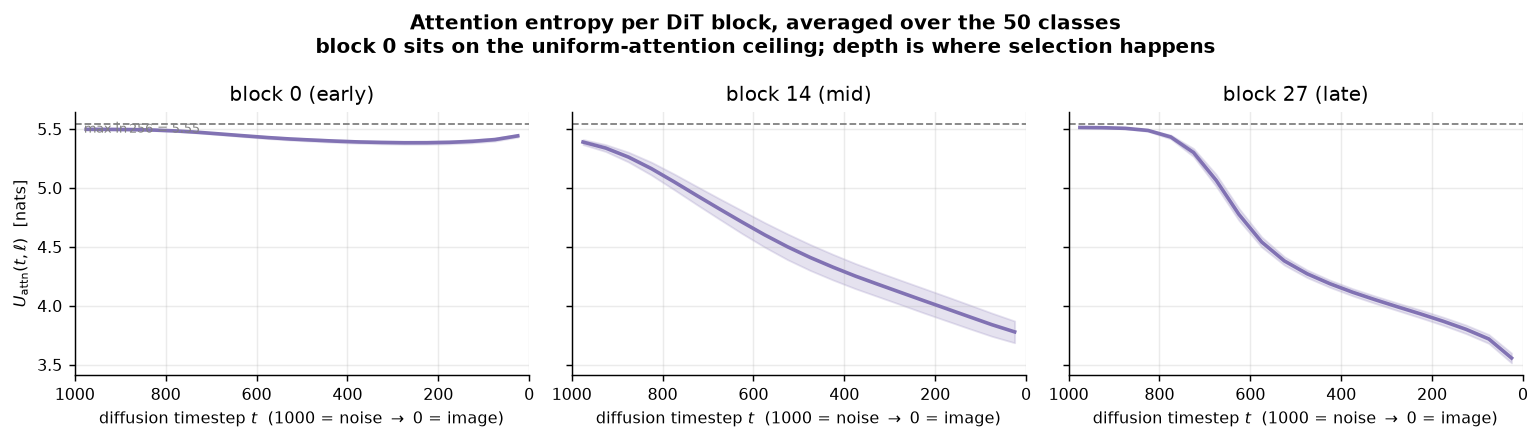

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, col, title in zip(axes,
        ["U_attn_block0", "U_attn_block14", "U_attn_block27"],
        ["block 0 (early)", "block 14 (mid)", "block 27 (late)"]):
    g = df.groupby("t_centre")[col]
    m, s = g.mean(), g.std()
    ax.plot(m.index, m.values, color="#8172B3", lw=2)
    ax.fill_between(m.index, m - s, m + s, color="#8172B3", alpha=.2)
    ax.axhline(LN256, color="grey", ls="--", lw=1)
    denoise_axis(ax); ax.set_title(title)
axes[0].set_ylabel(r"$U_\mathrm{attn}(t,\ell)$  [nats]")
axes[0].text(980, LN256 - .08, rf"max $\ln 256$ = {LN256:.2f}", fontsize=7, color="grey")
fig.suptitle("Attention entropy per DiT block, averaged over the 50 classes\n"
             "block 0 sits on the uniform-attention ceiling; depth is where selection happens",
             fontweight="bold")
plt.tight_layout(); plt.savefig("figures/fig3_attn_per_block.png", bbox_inches="tight"); plt.show()

### fig 4 — the proposal's key comparison: lemon vs crane

Unimodal **lemon (951)** against **both senses of "crane"** — bird (134) and machine (517).
The proposal predicts the ambiguous class shows a larger early-step spread. **Read the numbers
off this plot and state whether it actually does.** A measured negative result beats an
asserted hypothesis.

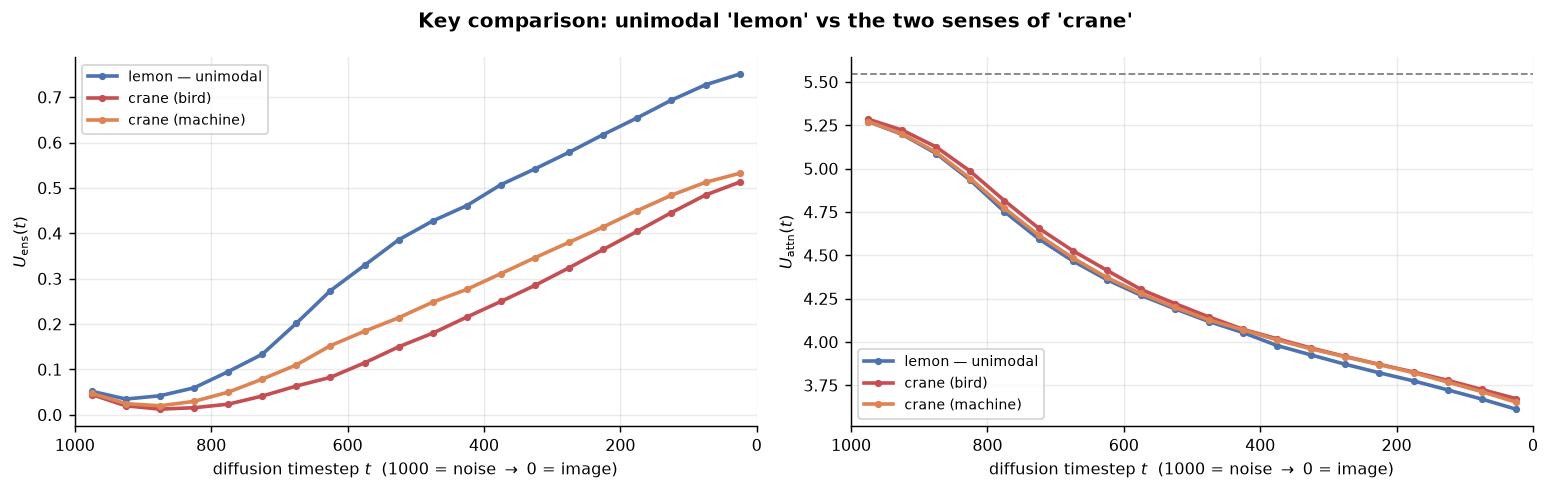

lemon — unimodal        U_ens early(t>=800) = 0.0470   late(t<=200) = 0.7065
crane (bird)            U_ens early(t>=800) = 0.0232   late(t<=200) = 0.4618
crane (machine)         U_ens early(t>=800) = 0.0304   late(t<=200) = 0.4946


In [11]:
key = [(951, "lemon — unimodal", "#4C72B0"),
       (134, "crane (bird)", "#C44E52"),
       (517, "crane (machine)", "#DD8452")]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for cid, lab, col in key:
    sub = df[df.class_id == cid].sort_values("t_centre")
    axes[0].plot(sub.t_centre, sub.U_ens,  color=col, lw=2, marker="o", ms=3, label=lab)
    axes[1].plot(sub.t_centre, sub.U_attn, color=col, lw=2, marker="o", ms=3, label=lab)
for ax, lab in zip(axes, [r"$U_\mathrm{ens}(t)$", r"$U_\mathrm{attn}(t)$"]):
    denoise_axis(ax); ax.set_ylabel(lab); ax.legend(fontsize=8)
axes[1].axhline(LN256, color="grey", ls="--", lw=1)
fig.suptitle("Key comparison: unimodal 'lemon' vs the two senses of 'crane'", fontweight="bold")
plt.tight_layout(); plt.savefig("figures/fig4_lemon_vs_crane.png", bbox_inches="tight"); plt.show()

# the numbers behind the claim
for cid, lab, _ in key:
    s = df[df.class_id == cid]
    e = s[s.t_centre >= 800].U_ens.mean(); l = s[s.t_centre <= 200].U_ens.mean()
    print(f"{lab:22s}  U_ens early(t>=800) = {e:.4f}   late(t<=200) = {l:.4f}")

### fig 5 — spatial: per-patch $U_\mathrm{ens}(t,p)$ on the 16×16 token grid

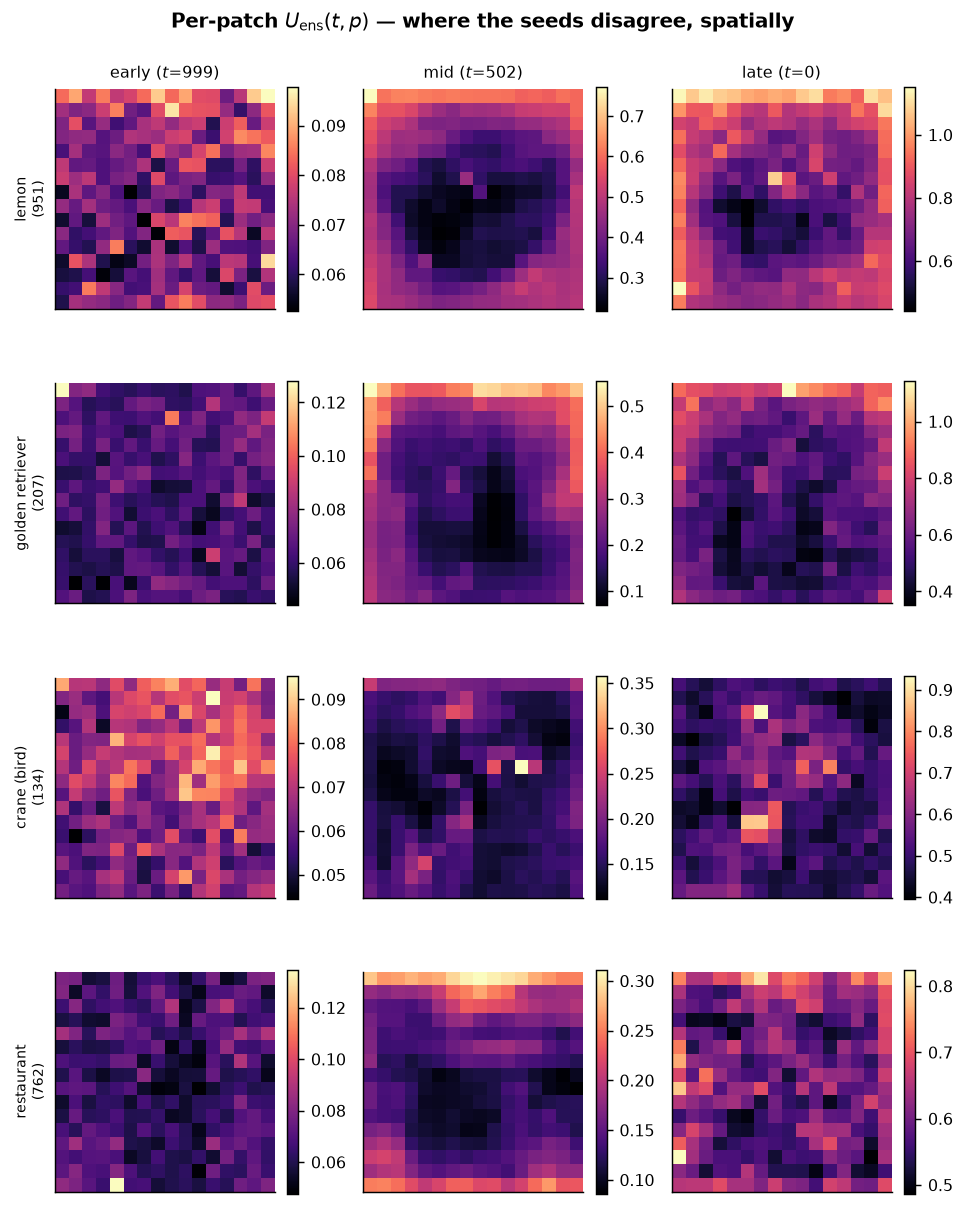

In [12]:
show = [951, 207, 134, 762]
fig, axes = plt.subplots(len(show), 3, figsize=(7.5, 2.4 * len(show)))
for r, cid in enumerate(show):
    m3, tv = heatmaps[str(cid)], heatmaps[f"{cid}_t"]
    nm = df[df.class_id == cid].class_name.iloc[0]
    for c in range(3):
        ax = axes[r, c]
        im = ax.imshow(m3[c], cmap="magma")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r == 0:
            ax.set_title(["early ($t$=%d)", "mid ($t$=%d)", "late ($t$=%d)"][c] % tv[c], fontsize=9)
        if c == 0:
            ax.set_ylabel(f"{nm}\n({cid})", fontsize=8)
        plt.colorbar(im, ax=ax, fraction=.046)
fig.suptitle(r"Per-patch $U_\mathrm{ens}(t,p)$ — where the seeds disagree, spatially",
             fontweight="bold")
plt.tight_layout(); plt.savefig("figures/fig5_patch_heatmaps.png", bbox_inches="tight"); plt.show()

## 8 · Summary table for the deck

Early = the noisy end of the path ($t\ge800$), late = the clean end ($t\le200$).

In [13]:
early = df[df.t_centre >= 800].groupby("difficulty")[["U_ens", "U_attn"]].mean()
late  = df[df.t_centre <= 200].groupby("difficulty")[["U_ens", "U_attn"]].mean()
summary = pd.concat({"early (t>=800, noise)": early, "late (t<=200, image)": late}, axis=1).round(4)
summary = summary.reindex(TIERS)
summary.to_csv("results/task1_early_late_by_difficulty.csv")
print(summary.to_string())

           early (t>=800, noise)         late (t<=200, image)        
                           U_ens  U_attn                U_ens  U_attn
difficulty                                                           
easy                      0.0414  5.1084               0.6093  3.6933
medium                    0.0265  5.1178               0.5403  3.6674
hard                      0.0268  5.1299               0.5007  3.6993


## 9 · $U_\text{route}$ — the proxy we could **not** compute

Routing variance
$$U_\text{route}(t,c)=\mathrm{Var}_m\Big[D^{\mathbf r^{(m)}}_\theta(x_t,t,c)\ \Big|\ z\Big]$$
is the **only epistemic** proxy, and the proposal calls it *"the linchpin"* — the
epistemic/aleatoric split in Tasks 3 and 5 is unjustified without it.

It is **only legitimate on a TREAD-trained model**: routing variance means something because the
network was *trained* as a distribution over sub-networks. Injecting routes (or MC-Dropout) into
a vanilla DiT, which never saw them during training, produces uninterpretable variance — the
proposal says this explicitly.

**Blocker: there is no public TREAD DiT-XL/2 checkpoint.** We cannot run it and we cannot
substitute vanilla DiT.

**What is ready:** a model-agnostic reference implementation — `routing_variance`,
`route_sanity`, `epi_ale_decomposition` in `notebooks/duq/proxies.py` — validated on a small
TREAD-trained DiT. Swapping in a real TREAD checkpoint is a one-function change.

**Decision needed from the curator:** obtain a TREAD checkpoint, or train a TREAD DiT-B/2
ourselves? This gates Tasks 2, 3 and 5.